In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# Create synthetic dataset

np.random.seed(42)
n = 200

df = pd.DataFrame({
    'Customer_ID': range(1, n+1),
    'Age': np.random.randint(18, 60, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Annual_Income': np.random.randint(15000, 100000, n),
    'Spending_Score': np.random.randint(1, 100, n)
})

# Save dataset
df.to_csv("customer_data.csv", index=False)

df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score
0,1,56,Male,51631,83
1,2,46,Female,87991,16
2,3,32,Female,19014,69
3,4,25,Male,26093,99
4,5,38,Female,33070,12


In [5]:
# Load dataset
df = pd.read_csv("customer_data.csv")

# Check missing values
print(df.isnull().sum())

# Convert Gender to numeric
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

df.head()

Customer_ID       0
Age               0
Gender            0
Annual_Income     0
Spending_Score    0
dtype: int64


,Customer_ID,Age,Gender,Annual_Income,Spending_Score
0,1,56,0,51631,83
1,2,46,1,87991,16
2,3,32,1,19014,69
3,4,25,0,26093,99
4,5,38,1,33070,12


In [7]:
# Select features
X = df[['Annual_Income', 'Spending_Score', 'Age']]

In [9]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\HP Z Book\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP Z Book\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP Z Book\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP Z Book\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memor

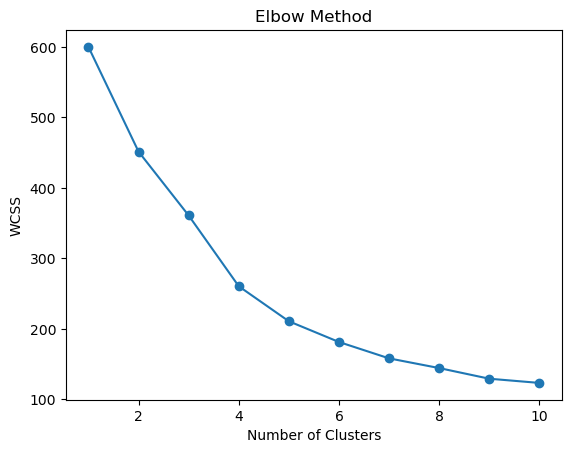

In [11]:
# Calculate WCSS for different K values
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [13]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

C:\Users\HP Z Book\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Cluster
0,1,56,0,51631,83,2
1,2,46,1,87991,16,1
2,3,32,1,19014,69,2
3,4,25,0,26093,99,2
4,5,38,1,33070,12,0


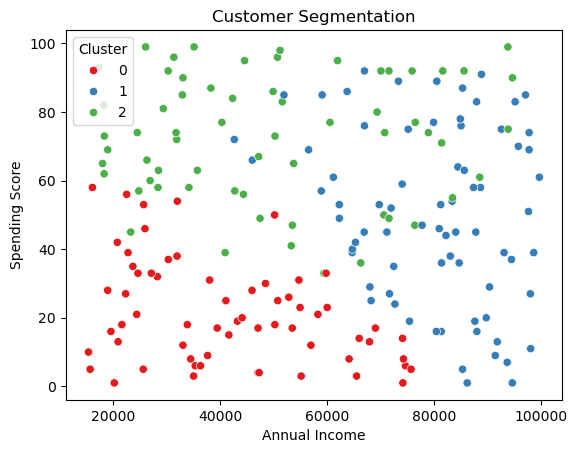

In [15]:
# Plot clusters (Income vs Spending Score)

plt.figure()
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [17]:
# Check cluster averages
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         Customer_ID        Age    Gender  Annual_Income  Spending_Score
Cluster                                                                 
0          99.444444  35.761905  0.539683   41739.698413       21.317460
1          95.945946  33.756757  0.567568   79798.189189       49.864865
2         106.904762  47.333333  0.492063   49675.619048       72.682540


In [19]:
# Show first few customers with clusters
df[['Customer_ID', 'Annual_Income', 'Spending_Score', 'Cluster']].head(10)

,Customer_ID,Annual_Income,Spending_Score,Cluster
0,1,51631,83,2
1,2,87991,16,1
2,3,19014,69,2
3,4,26093,99,2
4,5,33070,12,0
5,6,50777,25,0
6,7,71958,52,1
7,8,97074,85,1
8,9,25729,53,0
9,10,60017,23,0
